# Computational Checks for the Paper

This notebook checks the examples used in
**Algorithms for Collaborative Truck–Multi-Drone Delivery in the En-Route
Model**. It contains:

1. the $k=2$ tight maximum-coverage instance
   $\mathrm{Greedy}(2)/\mathrm{OPT}(2)=5/9$;
2. the greedy and two-schedule solution for the $k^\ast=2$
   minimum-fleet instance;
3. the two proper counterexamples; and
4. the proper witness for Case 1.

The points and their launch windows are printed before each calculation.


In [1]:
import math
from collections import namedtuple

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
TOL = 1.0e-10


## 1. Model and schedule checks

The truck speed is $1$, the drone speed is $v>1$, and the drone range is
$R$. The truck position is therefore the same as the time. For a delivery
$p=(x,y)$, the launch window is
$[\mathrm{es},\mathrm{ls}]$. The base paper defines

$$
a=\sqrt{(x-s)^2+y^2},\qquad b=sv^2+av-x,
$$

and gives the return function

$$
\operatorname{ret}(s,v,p)=
\begin{cases}
\operatorname{er}(p),&s<\operatorname{es}(p),\\[2pt]
\displaystyle s+\frac{s+av-x+
\sqrt{b^2-s(v^2-1)(b+s+av-x)}}{v^2-1},
&\operatorname{es}(p)\le s\le\operatorname{ls}(p),\\[8pt]
+\infty,&s>\operatorname{ls}(p).
\end{cases}
$$

Here $\operatorname{er}(p)$ is the return obtained when the launch is
$\operatorname{es}(p)$.

For a given order, the drone starts free at time $0$. If it is early for the
next delivery, it waits until the launch window opens. If that time is after
the latest launch, the order is not feasible.


### Basic calculations

The next two functions calculate a launch window and the return time. Values
are rounded only when a table is printed.


In [2]:
def calculate_es_ls(R, v, d):
    x, y = d
    m = R * math.sqrt(v * v - 1.0) / (2.0 * v)
    if y <= 0.0 or y > m + TOL:
        return None

    half_width = 0.5 * R * math.sqrt(max(0.0, 1.0 - (y / m) ** 2))
    center = x - R / (2.0 * v)
    return center - half_width, center + half_width


def ret(s, v, d):
    x, y = d
    a = math.sqrt((s - x) ** 2 + y ** 2)
    b = s * v * v + a * v - x
    q = v * v - 1.0
    discriminant = b * b - s * q * (b + s + a * v - x)
    return s + (s + a * v - x + math.sqrt(max(0.0, discriminant))) / q


### Greedy algorithm and schedule checks

`Greedy_Algorithm` chooses the available delivery with the smallest return
time. `Sequential_Greedy` repeats it for each drone. Deliveries missed by one
drone are considered by the next drone.

`check_feasibility` checks a fixed order of deliveries.


In [3]:
Delivery = namedtuple("Delivery", ["name", "es", "ls", "d"])


def Greedy_Algorithm(deliveries, R, v):
    s = 0.0
    SI = []
    missed = []
    L = deliveries.copy()

    while L:
        if s < L[0].es:
            s = L[0].es

        rmin = math.inf
        save = None
        for delivery in L:
            if delivery.es <= s and delivery.ls + TOL >= s:
                r = ret(s, v, delivery.d)
                if r < rmin - TOL:
                    rmin = r
                    save = delivery

        if save is None:
            missed.extend(L)
            break

        SI.append(
            {
                "delivery": save.name,
                "launch": s,
                "return": rmin,
                "latest_launch": save.ls,
            }
        )
        s = rmin

        L_next = []
        for delivery in L:
            if delivery.name == save.name:
                continue
            if delivery.ls + TOL < s:
                missed.append(delivery)
            else:
                L_next.append(delivery)
        L = L_next

    missed.sort(key=lambda item: (item.es, item.name))
    return SI, missed


def Sequential_Greedy(points, R, v, num_drones):
    L = []
    for name, d in points.items():
        window = calculate_es_ls(R, v, d)
        if window is not None:
            es, ls = window
            if ls >= 0.0:
                L.append(Delivery(name, es, ls, d))
    L.sort(key=lambda delivery: (delivery.es, delivery.name))

    SI_list = []
    for _ in range(num_drones):
        if not L:
            break
        SI, L = Greedy_Algorithm(L, R, v)
        SI_list.append(SI)

    return SI_list, L


def check_feasibility(points, order, R, v):
    s = 0.0
    trace = []
    for name in order:
        window = calculate_es_ls(R, v, points[name])
        if window is None:
            return False, trace
        es, ls = window
        launch = max(s, es)
        if launch > ls + TOL:
            return False, trace
        returned = ret(launch, v, points[name])
        trace.append(
            {
                "delivery": name,
                "launch": launch,
                "return": returned,
                "latest_launch": ls,
            }
        )
        s = returned
    return True, trace


def point_table(points, R, v):
    rows = []
    for name, (x, y) in points.items():
        earliest, latest = calculate_es_ls(R, v, (x, y))
        rows.append(
            {
                "point": name,
                "x": x,
                "y": y,
                "earliest launch": earliest,
                "latest launch": latest,
            }
        )
    return pd.DataFrame(rows).round(9)


def plot_schedules(points, panels, titles):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    colors = ["tab:blue", "tab:green", "tab:orange", "tab:purple"]
    for ax, schedules, title in zip(axes, panels, titles):
        ax.axhline(0, color="red", linewidth=2)

        for point_number, (name, d) in enumerate(points.items()):
            x, y = d
            ax.scatter(x, y, color="black", s=25)
            label_height = 5
            if point_number % 2 == 1:
                label_height = -10
            ax.annotate(
                name,
                (x, y),
                xytext=(3, label_height),
                textcoords="offset points",
                fontsize=9,
            )

        for schedule_number, schedule in enumerate(schedules):
            color = colors[schedule_number % len(colors)]
            for flight_number, row in enumerate(schedule):
                name = row["delivery"]
                x, y = points[name]
                launch = row["launch"]
                returned = row["return"]
                label = None
                if flight_number == 0:
                    label = f"schedule {schedule_number + 1}"
                ax.plot(
                    [launch, x, returned],
                    [0, y, 0],
                    color=color,
                    linestyle="--",
                    label=label,
                )
                ax.scatter(launch, 0, color=color, marker="^")
                ax.scatter(returned, 0, color=color, marker="v")

        ax.set_title(title)
        ax.set_xlabel("truck position / time")
        ax.set_ylabel("y")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## 2. Problem I: the tight $k=2$ maximum-coverage instance

Here $R=5/2$, $v=10$, and there are nine deliveries. Sequential Greedy
serves five deliveries with two drones. The other two schedules serve all nine,
so $\mathrm{OPT}(2)=9$.


**Points and launch windows**

,point,x,y,earliest launch,latest launch
0,d1,0.01,1.04,-0.800547,0.570547
1,d2,0.05,1.23,-0.260252,0.110252
2,d3,0.20,1.14,-0.424773,0.574773
3,d4,0.22,1.24,-0.001792,0.191792
4,d5,0.41,1.24,0.188208,0.381792
5,d6,0.44,1.24,0.218208,0.411792
6,d7,0.92,0.46,-0.366362,1.956362
7,d8,0.93,0.95,-0.001774,1.611774
8,d9,0.99,0.68,-0.181628,1.911628


**Greedy schedule 1**

,delivery,launch,return,latest_launch
0,d7,0.000000,0.189210,1.956362
1,d9,0.189210,0.385266,1.911628
2,d8,0.385266,0.595493,1.611774


**Greedy schedule 2**

...

**Better schedule 1**

,delivery,launch,return,latest_launch
0,d2,0.000000,0.247680,0.110252
1,d6,0.247680,0.497295,0.411792
2,d3,0.497295,0.741306,0.574773
3,d7,0.741306,0.837391,1.956362
4,d9,0.837391,0.975099,1.911628


**Better schedule 2**

,delivery,launch,return,latest_launch
0,d4,0.000000,0.249973,0.191792
1,d5,0.249973,0.499322,0.381792
2,d1,0.499322,0.741402,0.570547
3,d8,0.741402,0.933257,1.611774


PASS: Greedy(2)=5, OPT(2)=9, ratio=0.555555556=5/9.


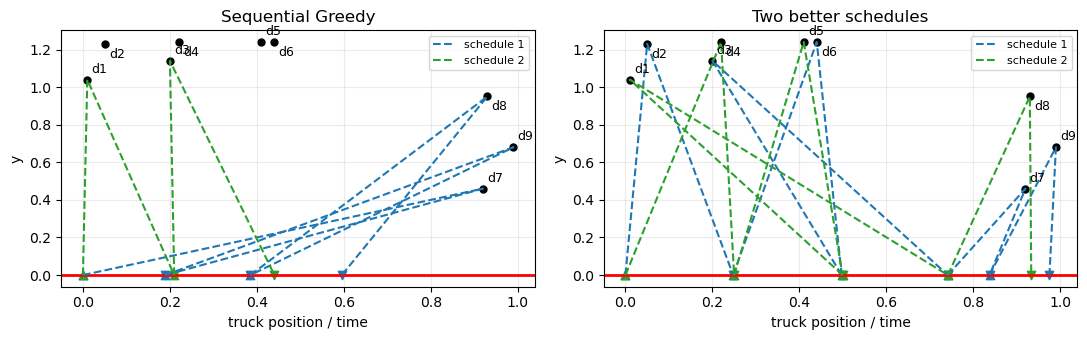

In [4]:
R_cov, v_cov = 2.5, 10.0
coverage_points = {
    "d1": (0.01, 1.04),
    "d2": (0.05, 1.23),
    "d3": (0.20, 1.14),
    "d4": (0.22, 1.24),
    "d5": (0.41, 1.24),
    "d6": (0.44, 1.24),
    "d7": (0.92, 0.46),
    "d8": (0.93, 0.95),
    "d9": (0.99, 0.68),
}
expected_greedy = [["d7", "d9", "d8"], ["d1", "d3"]]
optimal_schedules = [
    ["d2", "d6", "d3", "d7", "d9"],
    ["d4", "d5", "d1", "d8"],
]

display(Markdown("**Points and launch windows**"))
display(point_table(coverage_points, R_cov, v_cov))

greedy_traces, _ = Sequential_Greedy(
    coverage_points, R_cov, v_cov, 2
)
computed_greedy = []
for schedule in greedy_traces:
    order = []
    for row in schedule:
        order.append(row["delivery"])
    computed_greedy.append(order)
assert computed_greedy == expected_greedy
greedy_count = sum(len(schedule) for schedule in greedy_traces)
for number, schedule in enumerate(greedy_traces, start=1):
    display(Markdown(f"**Greedy schedule {number}**"))
    display(pd.DataFrame(schedule).round(9))

optimal_traces = []
for number, schedule in enumerate(optimal_schedules, start=1):
    feasible, trace = check_feasibility(coverage_points, schedule, R_cov, v_cov)
    assert feasible
    optimal_traces.append(trace)
    display(Markdown(f"**Better schedule {number}**"))
    display(pd.DataFrame(trace).round(9))
covered = [name for schedule in optimal_schedules for name in schedule]
assert set(covered) == set(coverage_points)

optimum_coverage = len(coverage_points)
ratio_cov = greedy_count / optimum_coverage
assert abs(ratio_cov - 5 / 9) < TOL
print(
    f"PASS: Greedy(2)={greedy_count}, "
    f"OPT(2)={optimum_coverage}, ratio={ratio_cov:.9f}=5/9."
)
plot_schedules(
    coverage_points,
    [greedy_traces, optimal_traces],
    ["Sequential Greedy", "Two better schedules"],
)


## 3. Problem II: the tight $k^\ast=2$ minimum-fleet instance

For $R=2/5$ and $v=8/5$, Sequential Greedy serves $2,1,1,1$ deliveries
with four drones. The two schedules shown below serve all five deliveries. The
paper proves that the optimum is $k^\ast=2$.


**Points and launch windows**

,point,x,y,earliest launch,latest launch
0,d1,0.10,0.07,-0.203771,0.153771
1,d2,0.12,0.14,-0.093521,0.083521
2,d3,0.16,0.12,-0.092942,0.162942
3,d4,0.20,0.09,-0.088425,0.238425
4,d5,0.29,0.01,-0.034589,0.364589


**Greedy schedule 1**

,delivery,launch,return,latest_launch
0,d1,0.000000,0.122186,0.153771
1,d5,0.122186,0.251884,0.364589


**Greedy schedule 2**

...

**Better schedule 1**

,delivery,launch,return,latest_launch
0,d2,0.000000,0.224392,0.083521
1,d4,0.224392,0.446938,0.238425


**Better schedule 2**

,delivery,launch,return,latest_launch
0,d1,0.000000,0.122186,0.153771
1,d3,0.122186,0.331792,0.162942
2,d5,0.331792,0.473519,0.364589


PASS: both displayed schedules are feasible; k*=2, k_greedy=4, ratio=2.0.


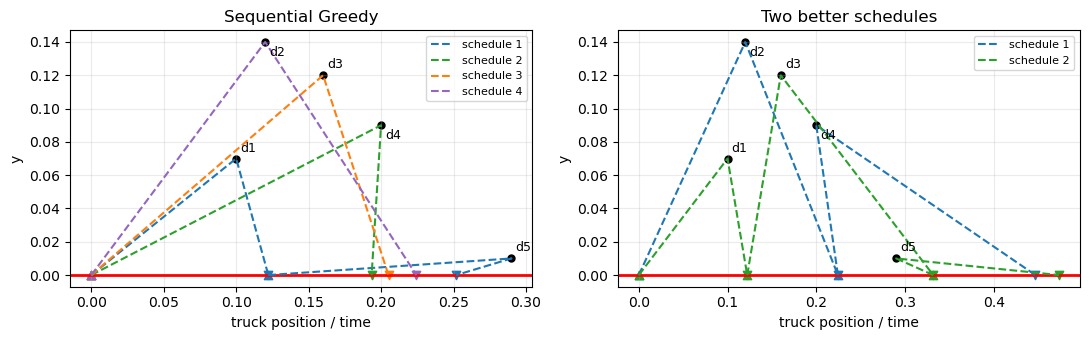

In [5]:
R_fleet, v_fleet = 0.4, 1.6
fleet_points = {
    "d1": (0.10, 0.07),
    "d2": (0.12, 0.14),
    "d3": (0.16, 0.12),
    "d4": (0.20, 0.09),
    "d5": (0.29, 0.01),
}
fleet_optimal_schedules = [
    ["d2", "d4"],
    ["d1", "d3", "d5"],
]
fleet_greedy_schedules = [["d1", "d5"], ["d4"], ["d3"], ["d2"]]

display(Markdown("**Points and launch windows**"))
display(point_table(fleet_points, R_fleet, v_fleet))

greedy_fleet_traces, unserved_fleet = Sequential_Greedy(
    fleet_points, R_fleet, v_fleet, len(fleet_points)
)
computed_fleet_greedy = []
for schedule in greedy_fleet_traces:
    order = []
    for row in schedule:
        order.append(row["delivery"])
    computed_fleet_greedy.append(order)
assert computed_fleet_greedy == fleet_greedy_schedules
assert not unserved_fleet
for number, schedule in enumerate(greedy_fleet_traces, start=1):
    display(Markdown(f"**Greedy schedule {number}**"))
    display(pd.DataFrame(schedule).round(9))

fleet_optimal_traces = []
for number, schedule in enumerate(fleet_optimal_schedules, start=1):
    feasible, trace = check_feasibility(fleet_points, schedule, R_fleet, v_fleet)
    assert feasible
    fleet_optimal_traces.append(trace)
    display(Markdown(f"**Better schedule {number}**"))
    display(pd.DataFrame(trace).round(9))

k_star = 2
k_greedy = len(greedy_fleet_traces)
assert k_greedy == 4
assert abs(k_greedy / k_star - 2.0) < TOL
print(
    f"PASS: both displayed schedules are feasible; "
    f"k*={k_star}, k_greedy={k_greedy}, "
    f"ratio={k_greedy / k_star:.1f}."
)
plot_schedules(
    fleet_points,
    [greedy_fleet_traces, fleet_optimal_traces],
    ["Sequential Greedy", "Two better schedules"],
)


## 4. Proper-instance counterexamples and Case-1 witness

A point set is *proper* when:

1. no launch window contains another; and
2. no delivery lies in another delivery's launch triangle with vertices
   $(\mathrm{es},0)$, $(x,y)$, and $(\mathrm{lr},0)$.

Here $\mathrm{lr}$ is the return time produced by launching at
$\mathrm{ls}$.

The code below checks both conditions and then checks the schedules.


### Checking properness

`is_proper` checks both conditions for every ordered pair of points.


In [6]:
def triangle_contains(apex, candidate, es, lr, tolerance=1e-12):
    xi, yi = apex
    xj, yj = candidate
    if yj < -tolerance or yj > yi + tolerance:
        return False
    fraction = yj / yi
    left = es + fraction * (xi - es)
    right = lr + fraction * (xi - lr)
    lo, hi = sorted((left, right))
    return lo - tolerance <= xj <= hi + tolerance


def is_proper(points, R, v):
    names = list(points)
    windows = {}
    for name in names:
        windows[name] = calculate_es_ls(R, v, points[name])

    for i in names:
        for j in names:
            if i == j:
                continue
            es_i, ls_i = windows[i]
            es_j, ls_j = windows[j]
            if es_i >= es_j - TOL and ls_i <= ls_j + TOL:
                return False
            if triangle_contains(
                points[j], points[i], es_j, ls_j + R / v
            ):
                return False
    return True


### Counterexample A: feasibility failure

The points have the same altitude. The unrestricted order
$(d_0,d_2,d_1)$ serves all three deliveries, while the $x$-ordered
schedule can serve at most two.


**Points and launch windows**

,point,x,y,earliest launch,latest launch
0,d0,0.001,0.023,-0.321818,0.073818
1,d1,0.025,0.023,-0.297818,0.097818
2,d2,0.052,0.023,-0.270818,0.124818


**Attempted $x$-order trace**

,delivery,launch,return,latest_launch
0,d0,0.000000,0.045942,0.073818
1,d1,0.045942,0.136597,0.097818


**Feasible crossing trace**

,delivery,launch,return,latest_launch
0,d0,0.000000,0.045942,0.073818
1,d2,0.045942,0.086964,0.124818
2,d1,0.086964,0.301984,0.097818


PASS: proper=True, unrestricted coverage=3, x-order coverage=2.


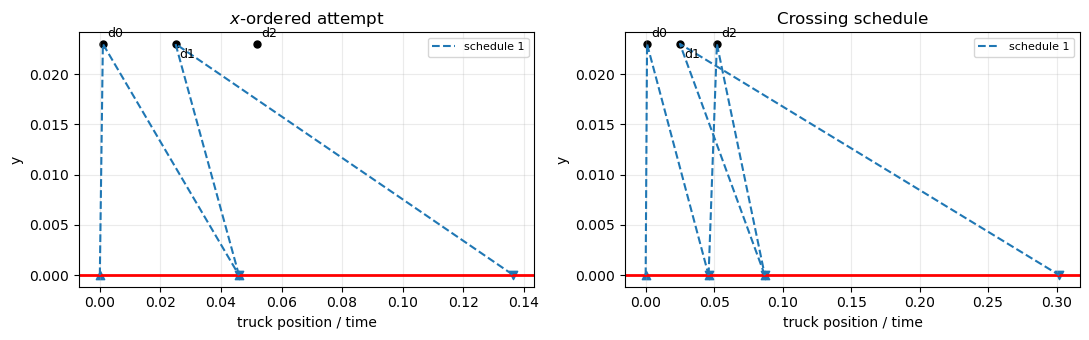

In [7]:
R_proper, v_proper = 0.4, 1.6
counterexample_A = {
    "d0": (0.001, 0.023),
    "d1": (0.025, 0.023),
    "d2": (0.052, 0.023),
}
proper_A = is_proper(counterexample_A, R_proper, v_proper)
assert proper_A

display(Markdown("**Points and launch windows**"))
display(point_table(counterexample_A, R_proper, v_proper))

feasible_x_A, trace_x_A = check_feasibility(
    counterexample_A, ["d0", "d1", "d2"], R_proper, v_proper
)
feasible_cross_A, trace_cross_A = check_feasibility(
    counterexample_A, ["d0", "d2", "d1"], R_proper, v_proper
)
unrestricted_A = len(trace_cross_A)
x_order_A = len(trace_x_A)
assert not feasible_x_A
assert feasible_cross_A
assert unrestricted_A == 3
assert x_order_A == 2

display(Markdown("**Attempted $x$-order trace**"))
display(pd.DataFrame(trace_x_A).round(6))
display(Markdown("**Feasible crossing trace**"))
display(pd.DataFrame(trace_cross_A).round(6))
print(
    f"PASS: proper={proper_A}, unrestricted coverage={unrestricted_A}, "
    f"x-order coverage={x_order_A}."
)
plot_schedules(
    counterexample_A,
    [[trace_x_A], [trace_cross_A]],
    ["$x$-ordered attempt", "Crossing schedule"],
)


### Counterexample B: completion-time failure

Both orders are feasible after $d_0$, but the $x$-ordered pair
$(d_1,d_2)$ completes later and misses $d_3$'s latest launch. The crossing
order $(d_2,d_1)$ serves all four.


**Points and launch windows**

,point,x,y,earliest launch,latest launch
0,d0,0.001,0.028,-0.320757,0.072757
1,d1,0.038,0.029,-0.283519,0.109519
2,d2,0.079,0.027,-0.242987,0.150987
3,d3,0.280,0.030,-0.041273,0.351273


**$x$-ordered pair**

,delivery,launch,return,latest_launch
0,d0,0.000000,0.056190,0.072757
1,d1,0.056190,0.149733,0.109519
2,d2,0.149733,0.395721,0.150987


**Crossing pair**

,delivery,launch,return,latest_launch
0,d0,0.00000,0.056190,0.072757
1,d2,0.05619,0.099450,0.150987
2,d1,0.09945,0.317616,0.109519


**Feasible crossing schedule**

,delivery,launch,return,latest_launch
0,d0,0.000000,0.056190,0.072757
1,d2,0.056190,0.099450,0.150987
2,d1,0.099450,0.317616,0.109519
3,d3,0.317616,0.464537,0.351273


PASS: proper=True, unrestricted coverage=4, x-order coverage=3, completion delay=0.078105.


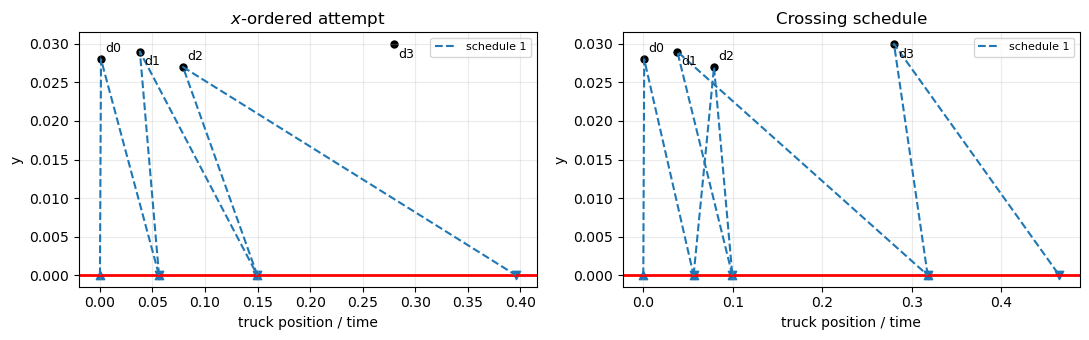

In [8]:
counterexample_B = {
    "d0": (0.001, 0.028),
    "d1": (0.038, 0.029),
    "d2": (0.079, 0.027),
    "d3": (0.280, 0.030),
}
proper_B = is_proper(counterexample_B, R_proper, v_proper)
assert proper_B

display(Markdown("**Points and launch windows**"))
display(point_table(counterexample_B, R_proper, v_proper))

feasible_pair_x_B, trace_pair_x_B = check_feasibility(
    counterexample_B, ["d0", "d1", "d2"], R_proper, v_proper
)
feasible_pair_cross_B, trace_pair_cross_B = check_feasibility(
    counterexample_B, ["d0", "d2", "d1"], R_proper, v_proper
)
completion_x_B = trace_pair_x_B[-1]["return"]
completion_cross_B = trace_pair_cross_B[-1]["return"]
feasible_x_B, trace_x_B = check_feasibility(
    counterexample_B,
    ["d0", "d1", "d2", "d3"],
    R_proper,
    v_proper,
)
feasible_cross_B, trace_cross_B = check_feasibility(
    counterexample_B,
    ["d0", "d2", "d1", "d3"],
    R_proper,
    v_proper,
)
unrestricted_B = len(trace_cross_B)
x_order_B = len(trace_x_B)
assert feasible_pair_x_B and feasible_pair_cross_B
assert completion_x_B > completion_cross_B
assert not feasible_x_B
assert feasible_cross_B
assert unrestricted_B == 4
assert x_order_B == 3

display(Markdown("**$x$-ordered pair**"))
display(pd.DataFrame(trace_pair_x_B).round(6))
display(Markdown("**Crossing pair**"))
display(pd.DataFrame(trace_pair_cross_B).round(6))
display(Markdown("**Feasible crossing schedule**"))
display(pd.DataFrame(trace_cross_B).round(6))
print(
    f"PASS: proper={proper_B}, unrestricted coverage={unrestricted_B}, "
    f"x-order coverage={x_order_B}, completion delay="
    f"{completion_x_B - completion_cross_B:.6f}."
)
plot_schedules(
    counterexample_B,
    [[trace_x_B], [trace_cross_B]],
    ["$x$-ordered attempt", "Crossing schedule"],
)


### Case-1 witness: the $x$-ordered continuation still finishes later

After serving $d_0$, the smaller-$x$ point $d_1$ has the smaller
occupancy, which is Case 1 of the published exchange proof. Both orders are
feasible, but $(d_1,d_2)$ completes later than $(d_2,d_1)$.


**Points and launch windows**

,point,x,y,earliest launch,latest launch
0,d0,0.052,0.023,-0.270818,0.124818
1,d1,0.324,0.023,0.001182,0.396818
2,d2,0.372,0.023,0.049182,0.444818


**$x$-ordered schedule**

,delivery,launch,return,latest_launch
0,d0,0.000000,0.049968,0.124818
1,d1,0.049968,0.262738,0.396818
2,d2,0.262738,0.351698,0.444818


**Crossing schedule**

,delivery,launch,return,latest_launch
0,d0,0.000000,0.049968,0.124818
1,d2,0.049968,0.299368,0.444818
2,d1,0.299368,0.336918,0.396818


O_d1(s)=0.212770 < O_d2(s)=0.249399; x-order completion is later by 0.014780.
PASS: proper=True and the Case-1 conclusion fails.


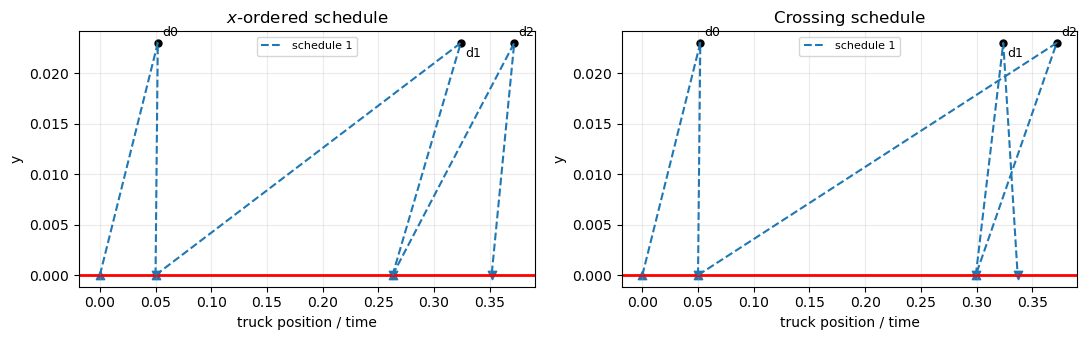

In [9]:
case1_witness = {
    "d0": (0.052, 0.023),
    "d1": (0.324, 0.023),
    "d2": (0.372, 0.023),
}
proper_C = is_proper(case1_witness, R_proper, v_proper)
assert proper_C

display(Markdown("**Points and launch windows**"))
display(point_table(case1_witness, R_proper, v_proper))
_, d0_trace = check_feasibility(
    case1_witness, ["d0"], R_proper, v_proper
)
s = d0_trace[-1]["return"]
es_d1, ls_d1 = calculate_es_ls(R_proper, v_proper, case1_witness["d1"])
es_d2, ls_d2 = calculate_es_ls(R_proper, v_proper, case1_witness["d2"])
assert es_d1 <= s <= ls_d1
assert es_d2 <= s <= ls_d2
occupancy_d1 = ret(s, v_proper, case1_witness["d1"]) - s
occupancy_d2 = ret(s, v_proper, case1_witness["d2"]) - s
feasible_case1_x, trace_case1_x = check_feasibility(
    case1_witness, ["d0", "d1", "d2"], R_proper, v_proper
)
feasible_case1_cross, trace_case1_cross = check_feasibility(
    case1_witness, ["d0", "d2", "d1"], R_proper, v_proper
)
completion_case1_x = trace_case1_x[-1]["return"]
completion_case1_cross = trace_case1_cross[-1]["return"]
assert occupancy_d1 < occupancy_d2
assert feasible_case1_x and feasible_case1_cross
assert completion_case1_x > completion_case1_cross
display(Markdown("**$x$-ordered schedule**"))
display(pd.DataFrame(trace_case1_x).round(6))
display(Markdown("**Crossing schedule**"))
display(pd.DataFrame(trace_case1_cross).round(6))
print(
    f"O_d1(s)={occupancy_d1:.6f} < O_d2(s)={occupancy_d2:.6f}; "
    f"x-order completion is later by "
    f"{completion_case1_x - completion_case1_cross:.6f}."
)
print(f"PASS: proper={proper_C} and the Case-1 conclusion fails.")
plot_schedules(
    case1_witness,
    [[trace_case1_x], [trace_case1_cross]],
    ["$x$-ordered schedule", "Crossing schedule"],
)
